In [ ]:
html = """
<html>
    <head>
        <title>Как подготовиться     к собеседованию</title>
        <style>
            body { color: black; }
        </style>
    </head>

    <body>
        <nav>
            Главная | Курсы | Войти
        </nav>

        <main>
            <h1>Как подготовиться к собеседованию</h1>

            <p>
                Решайте задачи по Python и повторяйте основы машинного обучения.
            </p>

            <p>
                Практикуйтесь регулярно, а не только перед интервью.
            </p>
        </main>

        <footer>
            Контакты: example@example.com
        </footer>

        <script>
            console.log("analytics");
        </script>
    </body>
</html>
"""

In [ ]:
from bs4 import BeautifulSoup

def extract_text(html: str) -> str:
  soup = BeautifulSoup(html, 'html.parser')
  for tag in soup(["script", "style", "nav", "footer"]):
    tag.extract()
  text = soup.get_text(separator='\n', strip=True)
  return text

print(extract_text(html))

Как подготовиться     к собеседованию
Как подготовиться к собеседованию
Решайте задачи по Python и повторяйте основы машинного обучения.
Практикуйтесь регулярно, а не только перед интервью.


In [ ]:
soup = BeautifulSoup(html, 'html.parser')
link = soup.find('h1')

print(link)

<h1>Как подготовиться к собеседованию</h1>


In [ ]:
for p in soup.find_all('p'):
  print(p.get_text())


                Решайте задачи по Python и повторяйте основы машинного обучения.
            

                Практикуйтесь регулярно, а не только перед интервью.
            


In [ ]:
soup.select('main p')

[<p>
                 Решайте задачи по Python и повторяйте основы машинного обучения.
             </p>,
 <p>
                 Практикуйтесь регулярно, а не только перед интервью.
             </p>]

In [ ]:
title = soup.find('h1')
print(title.get_text())

Как подготовиться к собеседованию


In [ ]:
def normalize_whitespace(text: str) -> str:
  lines = text.splitlines()
  cleaned_lines = []
  for l in lines:
    words = l.split()
    if words:
      cleaned_line = ' '.join(words)
      cleaned_lines.append(cleaned_line)
  return '\n'.join(cleaned_lines)

In [ ]:
extracted_text = extract_text(html)
normalized_text = normalize_whitespace(extracted_text)
print(extracted_text)
print(normalized_text)

Как подготовиться     к собеседованию
Как подготовиться к собеседованию
Решайте задачи по Python и повторяйте основы машинного обучения.
Практикуйтесь регулярно, а не только перед интервью.
Как подготовиться к собеседованию
Как подготовиться к собеседованию
Решайте задачи по Python и повторяйте основы машинного обучения.
Практикуйтесь регулярно, а не только перед интервью.


In [ ]:
pip install beautifulsoup4 trafilatura

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 15.1 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import trafilatura

html = Path('/content/practice_web_page.html').read_text(encoding='utf-8', errors='ignore')

beautifulsoup_text = normalize_whitespace(extract_text(html))

trafilatura_text = trafilatura.extract(html, include_comments=False, include_tables=False)

trafilatura_text = normalize_whitespace(trafilatura_text)

print("Beautiful Soup", len(beautifulsoup_text))
print(beautifulsoup_text[:1000])
print("\nTrafilatura", len(trafilatura_text))
print(trafilatura_text[:1000])

Beautiful Soup 1207
Как оценивать качество веб-текстов
Data Notes
Мы используем cookie для аналитики. Принять | Настроить
Полезный курс по NLP со скидкой 40%. Купить сейчас!
Как оценивать качество веб-текстов
Большой корпус не обязательно является хорошим корпусом. Если данные
состоят из меню, рекламных блоков и повторяющихся страниц, языковая
модель расходует вычисления на изучение веб-шаблонов вместо полезной речи.
Извлечение основного текста
Сначала из HTML извлекают содержательную часть страницы. Простой
BeautifulSoup умеет удалить заранее перечисленные элементы, а
специализированный экстрактор пытается определить основную статью
по структуре документа и плотности текста.
Проверка фильтров
Каждый фильтр необходимо проверять экспериментально. Для этого обучают
одинаковые модели на одинаковом количестве токенов и меняют только
способ подготовки данных.
Купить курс Купить курс Купить курс Купить курс Купить курс
Купить курс Купить курс Купить курс Купить курс Купить курс
Контакты авто

In [ ]:
dirty_text = """
   Нейронные      сети изучают текст.

   BM25    ранжирует     документы.
"""

expected = (
    "Нейронные сети изучают текст.\n"
    "BM25 ранжирует документы."
)

assert normalize_whitespace(dirty_text) == expected
assert normalize_whitespace(expected) == expected


In [ ]:
assert normalized_text.startswith('Как подготовиться')
assert '\n\n' not in normalized_text
assert "Главная | Курсы | Войти" not in normalized_text
assert "example@example.com" not in normalized_text
assert "console.log" not in normalized_text

In [ ]:
documents = [
    {
        "id": 1,
        "text": """
        Машинное обучение позволяет находить закономерности в данных.
        Для обучения модели данные разделяют на train, validation и test.
        """
    },
    {
        "id": 2,
        "text": "Купить курс"
    },
    {
        "id": 3,
        "text": """
        Python Python Python Python Python
        Python Python Python Python Python
        """
    },
    {
        "id": 4,
        "text": """
        Главная
        Каталог
        Войти
        Поиск
        Меню
        """
    },
]

In [ ]:
def check_min_length(text: str, min_character: int=50) -> bool:
  return len(text) > min_character

In [ ]:
from collections import Counter

def repeated_line_ratio(text: str) -> float:
  lines = text.splitlines()
  if not lines:
    return 0.0
  counter = Counter(lines)
  amount_of_repeated_lines = 0
  for c in counter.values():
    if c > 1:
      amount_of_repeated_lines += c
  return amount_of_repeated_lines / len(lines)


def short_lines_ratio(text: str, min_length: int = 30) -> float:
    lines = [
        line.strip()
        for line in text.splitlines()
        if line.strip()
    ]

    if not lines:
        return 0.0

    number_of_short_lines = 0

    for line in lines:
        if len(line) < min_length:
            number_of_short_lines += 1

    return number_of_short_lines / len(lines)


def get_quality_issues(text: str, min_length: int=50, max_repeated_ratio: float=0.5, max_short_lines_ratio: float=0.5) -> list[str]:
  issues = []
  if len(text) < min_length:
    issues.append("too_short")
  if repeated_line_ratio(text) >= max_repeated_ratio:
    issues.append("repeated_lines")
  if short_lines_ratio(text) >= max_short_lines_ratio:
    issues.append("short_lines")
  return issues



In [ ]:
for d in documents:
  text = normalize_whitespace(d['text'])
  issues = get_quality_issues(text)
  if issues:
    print(d['id'], "DECLINED:", issues)
  else:
    print(d['id'], "ACCEPTED")

1 ACCEPTED
2 DECLINED: ['too_short', 'short_lines']
3 DECLINED: ['repeated_lines']
4 DECLINED: ['too_short', 'short_lines']


In [ ]:
menu = """
Главная
Каталог
Ноутбукики
Телеффоны
Скидки
Войти
Подробнее
Купить
"""

article = """
Как подготовиться к собеседованию
Регулярная практика помогает закрепить алгоритмы и научиться уверенно писать код.
Разбор собственных ошибок обычно полезнеенее, чем пассивный просмотр решений.
"""

print(short_lines_ratio(menu))
print(short_lines_ratio(article))

1.0
0.0


In [ ]:
texts = [
    "Как подготовиться к собеседованию",
    "Python используется для анализа данных",
    "  КАК   ПОДГОТОВИТЬСЯ К СОБЕСЕДОВАНИЮ  ",
]


In [ ]:
import hashlib

def get_text_hash(text: str) -> str:
  normalized_text = normalize_whitespace(text).lower()
  encoded = normalized_text.encode('utf-8')
  return hashlib.sha256(encoded).hexdigest()

def remove_exact_duplicates(texts: list[str]) -> list[str]:
  seen_hashes = set()
  unique_texts = []
  for t in texts:
    t_hash = get_text_hash(t)
    if t_hash not in seen_hashes:
      seen_hashes.add(t_hash)
      unique_texts.append(t)
  return unique_texts

unique_texts = remove_exact_duplicates(texts)
print(unique_texts)
print(len(unique_texts))

['Как подготовиться к собеседованию', 'Python используется для анализа данных']
2


In [ ]:
def get_word_ngrams(text: str, n: int=3) -> set[tuple[str, ...]]:
  if n <= 0:
    raise ValueError("n должно быть больше 0")
  norm_text = normalize_whitespace(text).lower()
  words = norm_text.split()

  ngrams = set()

  for i in range(len(words) - n + 1):
    ngram = tuple(words[i:i+n])
    ngrams.add(ngram)

  return ngrams

def jaccard_similarity(first: set, second: set) -> float:
  union = first | second
  if not union:
    return 1.0
  intersection = first & second
  return len(intersection) / len(union)

def are_near_duplicates(text_a: str, text_b: str, n: int=2, threshold: float=0.9) -> bool:
  first_ngrams = get_word_ngrams(text_a, n)
  second_ngrams = get_word_ngrams(text_b, n)
  if not first_ngrams or not second_ngrams:
    first_norm = normalize_whitespace(text_a).lower()
    second_norm = normalize_whitespace(text_b).lower()
    return first_norm == second_norm

  similarity = jaccard_similarity(first_ngrams, second_ngrams)
  return similarity >= threshold


def remove_near_duplicates(texts: list[str], n: int=2, threshold: float=0.4) -> list[str]:
  unique_texts = []
  for t in texts:
    duples_found = False
    for u in unique_texts:
      if are_near_duplicates(t, u, n, threshold):
        duples_found = True
        break
    if not duples_found:
      unique_texts.append(t)
  return unique_texts

In [ ]:
text_a = """
Как подготовиться к техническому интервью:
решайте задачи и повторяйте основы Python.
"""

text_b = """
Как подготовиться к техническому интервью:
реште задачи и повторяйте основы Python каждый день.
"""

text_c = """
Сегодня кот спит на диване и смотрит в окно.
"""
n_a = get_word_ngrams(text_a, 2)
n_b = get_word_ngrams(text_b, 2)
n_c = get_word_ngrams(text_c, 2)

print("A & B:", jaccard_similarity(n_a, n_b))
print("A & C:", jaccard_similarity(n_a, n_c))
print("B & C:", jaccard_similarity(n_b, n_c))

for n in [1, 2, 3, 4, 5]:
  first = get_word_ngrams(text_a, n)
  second = get_word_ngrams(text_b, n)
  print(n, jaccard_similarity(first, second), are_near_duplicates(text_a, text_b, n, 0.4))

A & B: 0.4666666666666667
A & C: 0.0
B & C: 0.0
1 0.6 True
2 0.4666666666666667 True
3 0.3333333333333333 False
4 0.2 False
5 0.06666666666666667 False


In [ ]:
texts = [
    """
    Как подготовиться к техническому интервью:
    решайте задачи и повторяйте основы Python.
    """,
    """
    Сегодня кот спит на диване и смотрит в окно.
    """,
    """
    Как подготовиться к техническому интервью:
    решайте задачи и повторяйте основы Python каждый день.
    """,
    """
    Нейронные сети используются для обработки изображений.
    """,
]

unique_texts = remove_near_duplicates(texts, n=2, threshold=0.4)
for ut in unique_texts:
  print(normalize_whitespace(ut))

print(len(texts))
print(len(unique_texts))


Как подготовиться к техническому интервью:
решайте задачи и повторяйте основы Python.
Сегодня кот спит на диване и смотрит в окно.
Нейронные сети используются для обработки изображений.
4
3


In [ ]:
text = """
Напишите Анне на anna.petrov@example.com
или позвоните по номеру +7 (999) 123-45-67.
"""

import re


EMAIL_RE = re.compile(
    r"(?i)\b[A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,}\b"
)

PHONE_RE = re.compile(
    r"(?<!\d)(?:\+7|8)[\s-]?\(?\d{3}\)?"
    r"[\s-]?\d{3}[\s-]?\d{2}[\s-]?\d{2}(?!\d)"
)

In [ ]:
def anonymize_pii(text: str) -> tuple[str, dict[str, int]]:
  result, email_count = EMAIL_RE.subn('[EMAIL]', text)
  result, phone_count = PHONE_RE.subn('[PHONE]', result)
  report = {
      'emails': email_count,
      'phones': phone_count
  }
  return result, report

masked_text, report = anonymize_pii(text)
print(masked_text)
print(report)


Напишите Анне на [EMAIL]
или позвоните по номеру [PHONE].

{'emails': 1, 'phones': 1}


In [ ]:
masked_text, report = anonymize_pii(text)

assert "[EMAIL]" in masked_text
assert "[PHONE]" in masked_text
assert "anna.petrov@example.com" not in masked_text
assert "+7 (999) 123-45-67" not in masked_text
assert report == {"emails": 1, "phones": 1}

In [ ]:
documents = [
    {
        "id": 1,
        "html": """
        <main>
            <h1>Подготовка к интервью</h1>
            <p>Решайте задачи по Python и повторяйте машинное обучение.</p>
            <p>Практикуйтесь регулярно и анализируйте ошибки.</p>
        </main>
        """
    },
    {
        "id": 2,
        "html": """
        <nav>Главная Каталог Войти</nav>
        <main>Купить курс</main>
        """
    },
    {
        "id": 3,
        "html": """
        <main>
            <h1>Подготовка к интервью</h1>
            <p>Решайте задачи по Python и повторяйте машинное обучение.</p>
            <p>Практикуйтесь регулярно и анализируйте ошибки.</p>
        </main>
        """
    },
    {
        "id": 4,
        "html": """
        <main>
            <p>По вопросам обучения напишите на study@example.com
            или позвоните по номеру +7 (999) 123-45-67.</p>
        </main>
        """
    },
]

In [ ]:
prepared_documents = []
for d in documents:
  t = extract_text(d["html"])
  t = normalize_whitespace(t)

  prepared_documents.append({
      'id': d['id'],
      'text': t
  })

for pd in prepared_documents:
  print(pd['id'], pd['text'])

1 Подготовка к интервью
Решайте задачи по Python и повторяйте машинное обучение.
Практикуйтесь регулярно и анализируйте ошибки.
2 Купить курс
3 Подготовка к интервью
Решайте задачи по Python и повторяйте машинное обучение.
Практикуйтесь регулярно и анализируйте ошибки.
4 По вопросам обучения напишите на study@example.com
или позвоните по номеру +7 (999) 123-45-67.


In [ ]:
kept_documents = []
rejected_documents = []

for pd in prepared_documents:
  issues = get_quality_issues(pd['text'])
  if issues:
    rejected_documents.append({
        'id': pd['id'],
        'text': pd['text'],
        'issues': issues
    })
  else:
      kept_documents.append({
          'id': pd['id'],
          'text': pd['text']
      })

In [ ]:
print('Kept:')
for kd in kept_documents:
  print(kd['id'], kd['text'])
print('\nRejected:')
for rd in rejected_documents:
  print(rd['id'], rd['text'])
  print(rd['issues'])

Kept:
1 Подготовка к интервью
Решайте задачи по Python и повторяйте машинное обучение.
Практикуйтесь регулярно и анализируйте ошибки.
3 Подготовка к интервью
Решайте задачи по Python и повторяйте машинное обучение.
Практикуйтесь регулярно и анализируйте ошибки.
4 По вопросам обучения напишите на study@example.com
или позвоните по номеру +7 (999) 123-45-67.

Rejected:
2 Купить курс
['too_short', 'short_lines']


In [ ]:
def remove_exact_duplicate_documents(documents: list[dict]) -> tuple[list[dict], list[dict]]:
  seen_hashes = {}

  unique_documents = []
  duplicate_documents = []

  for d in documents:
    text_hash = get_text_hash(d['text'])
    if text_hash in seen_hashes:
      duplicate_documents.append({
          **d, 'duplicate_of': seen_hashes[text_hash]
      })
    else:
      unique_documents.append(d)
      seen_hashes[text_hash] = d['id']
  return unique_documents, duplicate_documents

In [ ]:
unique_documents, duplicate_documents = remove_exact_duplicate_documents(kept_documents)

print('Unique:')

for ud in unique_documents:
  print(ud['id'], ud['text'])
print('\nDuplicates:')
for dd in duplicate_documents:
  print(dd['id'], dd['text'])
  print('duplicate of', dd['duplicate_of'])

Unique:
1 Подготовка к интервью
Решайте задачи по Python и повторяйте машинное обучение.
Практикуйтесь регулярно и анализируйте ошибки.
4 По вопросам обучения напишите на study@example.com
или позвоните по номеру +7 (999) 123-45-67.

Duplicates:
3 Подготовка к интервью
Решайте задачи по Python и повторяйте машинное обучение.
Практикуйтесь регулярно и анализируйте ошибки.
duplicate of 1


In [ ]:
near_test_documents = [
    *unique_documents,
    {
        "id": 5,
        "text": (
            "Подготовка к техническому интервью\n"
            "Решайте задачи по Python и повторяйте машинное обучение. "
            "Практикуйтесь регулярно и анализируйте свои ошибки каждый день."
        ),
    },
]

In [ ]:
near_test_documents

[{'id': 1,
  'text': 'Подготовка к интервью\nРешайте задачи по Python и повторяйте машинное обучение.\nПрактикуйтесь регулярно и анализируйте ошибки.'},
 {'id': 4,
  'text': 'По вопросам обучения напишите на study@example.com\nили позвоните по номеру +7 (999) 123-45-67.'},
 {'id': 5,
  'text': 'Подготовка к техническому интервью\nРешайте задачи по Python и повторяйте машинное обучение. Практикуйтесь регулярно и анализируйте свои ошибки каждый день.'}]

In [ ]:
get_text_hash(near_test_documents[0]['text']) == get_text_hash(near_test_documents[2]['text'])

False

In [ ]:
first_ngrams = get_word_ngrams(near_test_documents[0]['text'], 2)
second_ngrams = get_word_ngrams(near_test_documents[2]['text'], 2)

print(jaccard_similarity(first_ngrams, second_ngrams))

0.6190476190476191


In [ ]:
def remove_near_duplicate_documents(documents: list[dict], n: int=2, threshold: float=0.4) -> tuple[list[dict], list[dict]]:
  unique_documents = []
  duplicate_documents = []

  for d in documents:
    duplicate_of = None
    for u in unique_documents:
      if are_near_duplicates(d['text'], u['text'], n, threshold):
        duplicate_of = u['id']
        break
    if duplicate_of is not None:
        duplicate_documents.append({
            **d,
            'duplicate_of': duplicate_of
        })
    else:
        unique_documents.append(d)

  return unique_documents, duplicate_documents

In [ ]:
near_unique_documents, near_duplicate_documents = remove_near_duplicate_documents(near_test_documents)

print('Unique:')

for ud in near_unique_documents:
  print(ud['id'], ud['text'])
print('\nDuplicates:')
for dd in near_duplicate_documents:
  print(dd['id'], dd['text'])
  print('duplicate of', dd['duplicate_of'])

Unique:
1 Подготовка к интервью
Решайте задачи по Python и повторяйте машинное обучение.
Практикуйтесь регулярно и анализируйте ошибки.
4 По вопросам обучения напишите на study@example.com
или позвоните по номеру +7 (999) 123-45-67.

Duplicates:
5 Подготовка к техническому интервью
Решайте задачи по Python и повторяйте машинное обучение. Практикуйтесь регулярно и анализируйте свои ошибки каждый день.
duplicate of 1


In [ ]:
final_documents = []

pii_totals = {
    'emails': 0,
    'phones': 0
}

for d in near_unique_documents:
  masked_text, report = anonymize_pii(d['text'])
  final_documents.append({
      **d, 'text': masked_text
  })
  pii_totals['emails'] += report['emails']
  pii_totals['phones'] += report['phones']

for d in final_documents:
  print(d['id'], d['text'])

print(f'{pii_totals=}')

1 Подготовка к интервью
Решайте задачи по Python и повторяйте машинное обучение.
Практикуйтесь регулярно и анализируйте ошибки.
4 По вопросам обучения напишите на [EMAIL]
или позвоните по номеру [PHONE].
pii_totals={'emails': 1, 'phones': 1}


In [ ]:
pipeline_report = {
    "raw_documents": 5,
    "quality_rejected": len(rejected_documents),
    "exact_duplicates": len(duplicate_documents),
    "near_duplicates": len(near_duplicate_documents),
    "final_documents": len(final_documents),
    "masked_emails": pii_totals["emails"],
    "masked_phones": pii_totals["phones"],
}

print(pipeline_report)

{'raw_documents': 5, 'quality_rejected': 1, 'exact_duplicates': 1, 'near_duplicates': 1, 'final_documents': 2, 'masked_emails': 1.0, 'masked_phones': 1.0}


In [ ]:
processed_count = (
    pipeline_report["quality_rejected"]
    + pipeline_report["exact_duplicates"]
    + pipeline_report["near_duplicates"]
    + pipeline_report["final_documents"]
)

assert processed_count == pipeline_report["raw_documents"]
assert pipeline_report["masked_emails"] == 1
assert pipeline_report["masked_phones"] == 1

In [ ]:
word_frequencies = {
    "низкий": 2,
    "ниже": 1,
    "новый": 1,
    "новее": 1,
}

In [ ]:
splits = {
    word: list(word) + ["</w>"] for word in word_frequencies
}

for w, s in splits.items():
  print(w, s)

низкий ['н', 'и', 'з', 'к', 'и', 'й', '</w>']
ниже ['н', 'и', 'ж', 'е', '</w>']
новый ['н', 'о', 'в', 'ы', 'й', '</w>']
новее ['н', 'о', 'в', 'е', 'е', '</w>']


In [ ]:
def count_pairs(
    splits: dict[str, list[str]],
    word_frequencies: dict[str, int],
) -> dict[tuple[str, str], int]:
  pair_counts = {}

  for w, s in splits.items():
    frequency = word_frequencies[w]
    for i in range(len(s) - 1):
      pair = (s[i], s[i+1])
      pair_counts[pair] = pair_counts.get(pair, 0) + frequency

  return pair_counts


In [ ]:
pair_counts = count_pairs(splits, word_frequencies)

for p, c in sorted(pair_counts.items(), key=lambda x: x[1], reverse=True):
  print(p, c)

('н', 'и') 3
('й', '</w>') 3
('и', 'з') 2
('з', 'к') 2
('к', 'и') 2
('и', 'й') 2
('е', '</w>') 2
('н', 'о') 2
('о', 'в') 2
('и', 'ж') 1
('ж', 'е') 1
('в', 'ы') 1
('ы', 'й') 1
('в', 'е') 1
('е', 'е') 1


In [ ]:
def merge_pair(symbols: list[str], pair: tuple[str, str]) -> list[str]:
  merged_symbols = []
  i = 0
  while i < len(symbols):
    if (
        i < len(symbols) - 1
        and symbols[i] == pair[0]
        and symbols[i + 1] == pair[1]
        ):
      merged_symbols.append(symbols[i] + symbols[i + 1])
      i += 2
    else:
      merged_symbols.append(symbols[i])
      i += 1
  return merged_symbols

In [ ]:
result = merge_pair(["н", "и", "з", "к", "и", "й", "</w>"], ('н', 'и'))
print(result)

['ни', 'з', 'к', 'и', 'й', '</w>']


In [ ]:
merge_pair(["а", "а", "а", "а", "а"], ('а', 'а'))

['аа', 'аа', 'а']

In [ ]:
best_pair = max(
    pair_counts,
    key=pair_counts.get,
)

print(best_pair)

('н', 'и')


In [ ]:
def merge_pairs_in_corpus(
    splits: dict[str, list[str]],
    pair: tuple[str, str]
) -> dict[str, list[str]]:
  updated_splits = {}
  for w, s in splits.items():
    updated_splits[w] = merge_pair(s, pair)
  return updated_splits

In [ ]:
pair_counts = count_pairs(splits, word_frequencies)
print(pair_counts)
best_pair = max(pair_counts, key=pair_counts.get)
print(best_pair)
splits = merge_pairs_in_corpus(splits, best_pair)
for w, s in splits.items():
  print(w, s)

{('ни', 'з'): 2, ('з', 'к'): 2, ('к', 'и'): 2, ('и', 'й'): 2, ('й', '</w>'): 3, ('ни', 'ж'): 1, ('ж', 'е'): 1, ('е', '</w>'): 2, ('н', 'о'): 2, ('о', 'в'): 2, ('в', 'ы'): 1, ('ы', 'й'): 1, ('в', 'е'): 1, ('е', 'е'): 1}
('й', '</w>')
низкий ['ни', 'з', 'к', 'и', 'й</w>']
ниже ['ни', 'ж', 'е', '</w>']
новый ['н', 'о', 'в', 'ы', 'й</w>']
новее ['н', 'о', 'в', 'е', 'е', '</w>']


In [ ]:
def train_bpe(word_frequencies: dict[str, int], number_of_merges: int) -> tuple[dict[str, list[str]], list[tuple[str, str]]]:
  splits = {
      word: list(word) + ['</w>'] for word in word_frequencies
  }

  merges = []
  for step in range(number_of_merges):
    pair_counts = count_pairs(splits, word_frequencies)
    if not pair_counts:
      break
    best_pair = max(pair_counts, key=pair_counts.get)
    splits = merge_pairs_in_corpus(splits, best_pair)
    merges.append(best_pair)
    print(f"{step+1}", best_pair, 'frequency:', pair_counts[best_pair])
  return splits, merges

In [ ]:
final_splits, merges = train_bpe(word_frequencies, 8)
print("Merges:", merges)

for w, s in final_splits.items():
  print(w, s)

1 ('н', 'и') frequency: 3
2 ('й', '</w>') frequency: 3
3 ('ни', 'з') frequency: 2
4 ('низ', 'к') frequency: 2
5 ('низк', 'и') frequency: 2
6 ('низки', 'й</w>') frequency: 2
7 ('е', '</w>') frequency: 2
8 ('н', 'о') frequency: 2
Merges: [('н', 'и'), ('й', '</w>'), ('ни', 'з'), ('низ', 'к'), ('низк', 'и'), ('низки', 'й</w>'), ('е', '</w>'), ('н', 'о')]
низкий ['низкий</w>']
ниже ['ни', 'ж', 'е</w>']
новый ['но', 'в', 'ы', 'й</w>']
новее ['но', 'в', 'е', 'е</w>']


In [ ]:
created_tokens = []

for f, s in merges:
  created_tokens.append(f+s)

print(created_tokens)

['ни', 'й</w>', 'низ', 'низк', 'низки', 'низкий</w>', 'е</w>', 'но']


In [ ]:
def bpe_encode(word: str, merges: list[tuple[str, str]]) -> list[str]:
  symbols = list(word) + ['</w>']
  for pair in merges:
    symbols = merge_pair(symbols, pair)
  return symbols

In [ ]:
for w in ["низкий", "ниже", "низина", "новее", "ножницы"]:
  print(w, '->', bpe_encode(w, merges))

низкий -> ['низкий</w>']
ниже -> ['ни', 'ж', 'е</w>']
низина -> ['низ', 'и', 'н', 'а', '</w>']
новее -> ['но', 'в', 'е', 'е</w>']
ножницы -> ['но', 'ж', 'ни', 'ц', 'ы', '</w>']


In [ ]:
def build_bpe_vocabulary(word_frequencies: dict[str, int], merges: list[tuple[str, str]]) -> list[str]:
  vocabulary = {'<UNK>', '</w>'}
  for w in word_frequencies:
    for c in w:
      vocabulary.add(c)
  for f, s in merges:
    vocabulary.add(f+s)
  other_tokens = sorted(vocabulary - {'<UNK>'})
  return ['<UNK>', *other_tokens]

In [ ]:
vocabulary = build_bpe_vocabulary(word_frequencies, merges)
token_to_id = {token: idx for idx, token in enumerate(vocabulary)}

print(vocabulary)
print(token_to_id)

['<UNK>', '</w>', 'в', 'е', 'е</w>', 'ж', 'з', 'и', 'й', 'й</w>', 'к', 'н', 'ни', 'низ', 'низк', 'низки', 'низкий</w>', 'но', 'о', 'ы']
{'<UNK>': 0, '</w>': 1, 'в': 2, 'е': 3, 'е</w>': 4, 'ж': 5, 'з': 6, 'и': 7, 'й': 8, 'й</w>': 9, 'к': 10, 'н': 11, 'ни': 12, 'низ': 13, 'низк': 14, 'низки': 15, 'низкий</w>': 16, 'но': 17, 'о': 18, 'ы': 19}


In [ ]:
def bpe_encode_to_ids(word: str, merges: list[tuple[str, str]], token_to_id: dict[str, int]) -> list[int]:
  tokens = bpe_encode(word, merges)
  unknown_id = token_to_id['<UNK>']
  token_ids = []
  for t in tokens:
    token_id = token_to_id.get(t, unknown_id)
    token_ids.append(token_id)
  return token_ids

In [ ]:
for w in ["низкий", "ниже", "низина", "новее", "ножницы"]:
  tokens = bpe_encode(w, merges)
  token_ids = bpe_encode_to_ids(w, merges, token_to_id)
  print(w)
  print(tokens)
  print(token_ids)

низкий
['низкий</w>']
[16]
ниже
['ни', 'ж', 'е</w>']
[12, 5, 4]
низина
['низ', 'и', 'н', 'а', '</w>']
[13, 7, 11, 0, 1]
новее
['но', 'в', 'е', 'е</w>']
[17, 2, 3, 4]
ножницы
['но', 'ж', 'ни', 'ц', 'ы', '</w>']
[17, 5, 12, 0, 19, 1]


In [ ]:
id_to_token = {idx: token for token, idx in token_to_id.items()}

def bpe_decode_ids(token_ids: list[int], id_to_token: dict[int, str]) -> str:
  tokens = []

  for t in token_ids:
    token = id_to_token.get(t, '<UNK>')
    tokens.append(token)
  text = ''.join(tokens)
  text = text.replace('</w>', ' ')
  return text.strip()

In [ ]:
for w in ["низкий", "ниже", "низина", "новее", "ножницы"]:
  tokens = bpe_encode(w, merges)
  token_ids = bpe_encode_to_ids(w, merges, token_to_id)
  decoded_text = bpe_decode_ids(token_ids, id_to_token)
  print(w, '->', tokens, '->', token_ids, '->',decoded_text)

низкий -> ['низкий</w>'] -> [16] -> низкий
ниже -> ['ни', 'ж', 'е</w>'] -> [12, 5, 4] -> ниже
низина -> ['низ', 'и', 'н', 'а', '</w>'] -> [13, 7, 11, 0, 1] -> низин<UNK>
новее -> ['но', 'в', 'е', 'е</w>'] -> [17, 2, 3, 4] -> новее
ножницы -> ['но', 'ж', 'ни', 'ц', 'ы', '</w>'] -> [17, 5, 12, 0, 19, 1] -> ножни<UNK>ы


In [ ]:
wordpiece_vocabulary = {
    "[UNK]",
    "токен",
    "токенизация",
    "##изация",
    "##ация",
    "модел",
    "##и",
    "##рует",
    "текст",
}

In [ ]:
def find_longest_wordpiece(word: str, start: int, vocabulary: set[str]) -> tuple[str | None, int]:
  for end in range(len(word), start, -1):
    piece = word[start: end]

    if start > 0:
      piece = '##' + piece
    if piece in vocabulary:
      return piece, end
  return None, start



In [ ]:
def wordpiece_encode(word: str, vocabulary: set[str]) -> list[str]:
  tokens = []
  start = 0
  while start < len(word):
    piece, end = find_longest_wordpiece(word, start, vocabulary)
    if piece is None:
      return ['[UNK]']
    tokens.append(piece)
    start = end
  return tokens

In [ ]:
for w in [
    "токенизация",
    "моделирует",
    "текст",
    "неизвестно",
]:
  print(w, '->', wordpiece_encode(w, wordpiece_vocabulary))

токенизация -> ['токенизация']
моделирует -> ['модел', '##и', '##рует']
текст -> ['текст']
неизвестно -> ['[UNK]']


In [ ]:
def wordpiece_decode(tokens: list[str]) -> str:
  result = ''
  for t in tokens:
    if t.startswith('##'):
      result += t[2:]
    else: result += t
  return result

In [ ]:
wordpiece_decode(["модел", "##и", "##рует"])

'моделирует'

In [ ]:
token_probabilities = {
    "м": 0.1,
    "а": 0.1,
    "ма": 0.4,
    "мама": 0.05,
}

In [ ]:
def find_tokens_ending_at(word: str, end: int, token_probabilities: dict[str, float]) -> list[tuple[int, str]]:
  candidates = []
  for start in range(end):
    token = word[start : end]
    if token in token_probabilities:
      candidates.append((start, token))
  return candidates

In [ ]:
for end in range(1, len('мама') + 1):
  candidates = find_tokens_ending_at('мама', end, token_probabilities)
  print('end=', end)
  print('prefix=', 'мама'[:end])
  print('candidates=', candidates)

end= 1
prefix= м
candidates= [(0, 'м')]
end= 2
prefix= ма
candidates= [(0, 'ма'), (1, 'а')]
end= 3
prefix= мам
candidates= [(2, 'м')]
end= 4
prefix= мама
candidates= [(0, 'мама'), (2, 'ма'), (3, 'а')]


In [ ]:
import math

def unigram_best_scores(word: str, token_probabilities: dict[str, float]) -> tuple[list[float], list[tuple[int, str] | None]]:
  best_scores = [-math.inf] * (len(word)+1)
  best_scores[0] = 0.0
  previous = [None] * (len(word)+1)
  for end in range(1, len(word) + 1):
    candidates = find_tokens_ending_at(word, end, token_probabilities)
    for start, token in candidates:
      if best_scores[start] == -math.inf:
        continue
      candidate_score = (best_scores[start] + math.log(token_probabilities[token]))
      if candidate_score > best_scores[end]:
        best_scores[end] = candidate_score
        previous[end] = (start, token)
  return best_scores, previous

In [ ]:
scores, previous = unigram_best_scores('мама', token_probabilities)
print(scores)
print(previous)

[0.0, -2.3025850929940455, -0.916290731874155, -3.2188758248682006, -1.83258146374831]
[None, (0, 'м'), (0, 'ма'), (2, 'м'), (2, 'ма')]


In [ ]:
def restore_tokens(word: str, previous: list[tuple[int, str] | None]) -> list[str]:
  tokens = []
  end = len(word)
  while end > 0:
    step = previous[end]
    if step is None:
      return ['[UNK]']
    start, token = step
    tokens.append(token)
    end = start
  tokens.reverse()
  return tokens


In [ ]:
scores, previous = unigram_best_scores('мама', token_probabilities)
tokens = restore_tokens('мама', previous)
tokens

['ма', 'ма']

In [ ]:
def unigram_encode(word: str, token_probabilities: dict[str, float]) -> tuple[list[str], float]:
  best_scores, previous = unigram_best_scores(word, token_probabilities)
  tokens = restore_tokens(word, previous)
  final_score = best_scores[-1]
  return tokens, final_score

In [ ]:
for w in ["мама", "мам", "кот"]:
  tokens, score = unigram_encode(w, token_probabilities)
  print(w, '->', tokens)
  print(score)

мама -> ['ма', 'ма']
-1.83258146374831
мам -> ['ма', 'м']
-3.2188758248682006
кот -> ['[UNK]']
-inf


In [ ]:
def sentencepiece_prepare(text: str) -> str:
  normalized = ' '.join(text.split())
  if not normalized:
    return ''
  return '▁'+normalized.replace(' ', '▁')

def sentencepiece_decode(tokens: list[str]) -> str:
  text = ''.join(tokens)
  text = text.replace('▁', ' ')
  return text.strip()

In [ ]:
prepared = sentencepiece_prepare(    "  модель   читает текст  "
)
print(prepared)
assert prepared == "▁модель▁читает▁текст"

tokens = [
    "▁модель",
    "▁читает",
    "▁текст",
]

decoded = sentencepiece_decode(tokens)
print(decoded)

assert decoded == "модель читает текст"

▁модель▁читает▁текст
модель читает текст


In [ ]:
vocabulary = [
    "[PAD]",  # 0
    "[UNK]",  # 1
    "[BOS]",  # 2
    "[EOS]",  # 3
    "привет", # 4
    "мир",    # 5
    "!",      # 6
]

In [ ]:
token_to_id = {t: i for i, t in enumerate(vocabulary)}

print(token_to_id)

{'[PAD]': 0, '[UNK]': 1, '[BOS]': 2, '[EOS]': 3, 'привет': 4, 'мир': 5, '!': 6}


In [ ]:
def encode_tokens(tokens: list[str], token_to_id: dict[str, int], add_special_tokens: bool = True) -> list[int]:
  token_ids = []
  if add_special_tokens:
    token_ids.append(token_to_id['[BOS]'])
  unknown_token = token_to_id['[UNK]']
  for t in tokens:
    token_id = token_to_id.get(t, unknown_token)
    token_ids.append(token_id)
  if add_special_tokens:
    token_ids.append(token_to_id['[EOS]'])
  return token_ids

def pad_sequences(sequences: list[list[int]], pad_id: int) -> tuple[list[list[int]], list[list[int]]]:
  if not sequences:
    return [], []

  max_length = max(len(s) for s in sequences)
  padded_sequences = []
  attention_masks = []

  for s in sequences:
    padding_length = max_length - len(s)
    padded_sequence = (s + [pad_id] * padding_length)
    attention_mask = ([1] * len(s) + [0] * padding_length)
    padded_sequences.append(padded_sequence)
    attention_masks.append(attention_mask)
  return padded_sequences, attention_masks

In [ ]:
sequences = [
    encode_tokens(
        ["привет", "!"],
        token_to_id,
    ),
    encode_tokens(
        ["привет", "мир", "!"],
        token_to_id,
    ),
    encode_tokens(
        ["кот"],
        token_to_id,
    ),
]

print(sequences)

[[2, 4, 6, 3], [2, 4, 5, 6, 3], [2, 1, 3]]


In [ ]:
padded, masks = pad_sequences(sequences, token_to_id['[PAD]'])
print('Input IDs:')
for r in padded:
  print(r)
print('Attention masks:')
for r in masks:
  print(r)

Input IDs:
[2, 4, 6, 3, 0]
[2, 4, 5, 6, 3]
[2, 1, 3, 0, 0]
Attention masks:
[1, 1, 1, 1, 0]
[1, 1, 1, 1, 1]
[1, 1, 1, 0, 0]


In [ ]:
import torch

input_ids = torch.tensor(padded, dtype=torch.long)
attention_masks = torch.tensor(masks, dtype=torch.long)

print(input_ids.shape)
print(attention_masks.shape)

torch.Size([3, 5])
torch.Size([3, 5])


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')
text = [
    "Привет!",
    "Студент изучает токенизацию.",
    "Неизвестнейшее слово",
]
batch = tokenizer(text, padding=True, truncation=True)

print(batch.keys())
for i, t in enumerate(text):
  input_ids = batch['input_ids'][i]
  attention_mask = batch['attention_mask'][i]
  tokens = tokenizer.convert_ids_to_tokens(input_ids)
  print('\nText:', t)
  print('Tokens:', tokens)
  print('IDs:', input_ids)
  print('Mask:', attention_mask)

KeysView({'input_ids': [[101, 14337, 41102, 106, 102, 0, 0, 0, 0, 0, 0, 0], [101, 526, 12803, 87161, 10387, 49299, 25471, 84964, 15065, 71599, 119, 102], [101, 21124, 39457, 14149, 11567, 17000, 32381, 42638, 102, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]]})

Text: Привет!
Tokens: ['[CLS]', 'При', '##вет', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
IDs: [101, 14337, 41102, 106, 102, 0, 0, 0, 0, 0, 0, 0]
Mask: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]

Text: Студент изучает токенизацию.
Tokens: ['[CLS]', 'С', '##ту', '##дент', 'из', '##уч', '##ает', 'ток', '##ени', '##зацию', '.', '[SEP]']
IDs: [101, 526, 12803, 87161, 10387, 49299, 25471, 84964, 15065, 71599, 119, 102]
Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Text: Неизвест

In [ ]:
decoded = tokenizer.decode(batch['input_ids'][1], skip_special_tokens=True)
print(decoded)
print(tokenizer.vocab_size)

Студент изучает токенизацию.
119547


In [ ]:
text = (
    "Студент ищет беспроводные наушники для учёбы: "
    "важны шумоподавление, цена до 5 000 рублей "
    "и быстрая доставка."
)

tokenizers = {
    "BPE — Qwen": AutoTokenizer.from_pretrained(
        "Qwen/Qwen3.6-27B"
    ),
    "WordPiece — mBERT": AutoTokenizer.from_pretrained(
        "bert-base-multilingual-cased"
    ),
    "SentencePiece/Unigram — mT5": AutoTokenizer.from_pretrained(
        "google/mt5-small"
    ),
}

for n, t in tokenizers.items():
  encoding = t(text, add_special_tokens=False)
  tokens = t.convert_ids_to_tokens(encoding['input_ids'])
  decoded = t.decode(encoding['input_ids'])
  print('\n', n)
  print("Количество:", len(tokens))
  print('Токены:', tokens)
  print("Декодирование:", decoded)


 BPE — Qwen
Количество: 34
Токены: ['Ð¡ÑĤ', 'ÑĥÐ´', 'ÐµÐ½ÑĤ', 'ĠÐ¸', 'ÑīÐµÑĤ', 'ĠÐ±ÐµÑģÐ¿ÑĢÐ¾Ð²Ð¾Ð´', 'Ð½ÑĭÐµ', 'ĠÐ½Ð°ÑĥÑĪ', 'Ð½Ð¸ÐºÐ¸', 'ĠÐ´Ð»Ñı', 'ĠÑĥÑĩÑĳ', 'Ð±Ñĭ', ':', 'ĠÐ²Ð°Ð¶', 'Ð½Ñĭ', 'ĠÑĪÑĥÐ¼', 'Ð¾Ð¿Ð¾', 'Ð´Ð°', 'Ð²Ð»ÐµÐ½Ð¸Ðµ', ',', 'ĠÑĨÐµÐ½Ð°', 'ĠÐ´Ð¾', 'Ġ', '5', 'Ġ', '0', '0', '0', 'ĠÑĢÑĥÐ±Ð»ÐµÐ¹', 'ĠÐ¸', 'ĠÐ±Ñĭ', 'ÑģÑĤÑĢÐ°Ñı', 'ĠÐ´Ð¾ÑģÑĤÐ°Ð²ÐºÐ°', '.']
Декодирование: Студент ищет беспроводные наушники для учёбы: важны шумоподавление, цена до 5 000 рублей и быстрая доставка.

 WordPiece — mBERT
Количество: 41
Токены: ['С', '##ту', '##дент', 'и', '##ще', '##т', 'б', '##ес', '##про', '##вод', '##ные', 'на', '##уш', '##ники', 'для', 'у', '##ч', '##ё', '##бы', ':', 'ва', '##жны', 'ш', '##ум', '##оп', '##ода', '##вление', ',', 'це', '##на', 'до', '5', '000', 'рублей', 'и', 'бы', '##стра', '##я', 'доста', '##вка', '.']
Декодирование: Студент ищет беспроводные наушники для учёбы : важны шумоподавление, цена до 5 000 рублей и быстрая доставка.

 SentencePiece/Unigram — mT5
Количеств

In [ ]:
import re

def split_special_tokens(text: str, special_tokens: set[str]) -> list[str]:
  ordered_tokens = sorted(special_tokens, key=len, reverse=True)
  escaped_tokens = [re.escape(t) for t in ordered_tokens]

  pattern = (
      "("
      + "|".join(escaped_tokens) +
      ")"
  )
  return [p for p in re.split(pattern, text) if p]

def encode_preserving_special_tokens(text: str, special_tokens: set[str]) -> list[str]:
  parts = split_special_tokens(text, special_tokens)
  encoded = []
  for p in parts:
    if p in special_tokens:
      encoded.append(p)
    else:
      encoded.extend(list(p))
  return encoded

In [ ]:
message = (
    "<|user|>Привет!<|end|>"
    "<|assistant|>Здравствуйте!<|end|>"
)

registered_special = {
    "<|user|>",
    "<|assistant|>",
    "<|end|>",
}

result = encode_preserving_special_tokens(
    message,
    registered_special,
)

print(result)

['<|user|>', 'П', 'р', 'и', 'в', 'е', 'т', '!', '<|end|>', '<|assistant|>', 'З', 'д', 'р', 'а', 'в', 'с', 'т', 'в', 'у', 'й', 'т', 'е', '!', '<|end|>']


In [ ]:
documents = [
    "кот спит на диване",
    "собака спит на ковре",
    "кот играет с мячом",
    'собака играет на улице'
]

In [ ]:
def tokenize_for_tf_idf(text: str) -> list[str]:
  return (text.lower()).split()

def build_word_vocabulary(documents: list[list[str]]) -> list[str]:
  vocabulary = set()
  for d in documents:
    for t in d:
      vocabulary.add(t)
  return sorted(vocabulary)


In [ ]:
tokenized_documents = [tokenize_for_tf_idf(d) for d in documents]
vocabulary = build_word_vocabulary(tokenized_documents)
print(tokenized_documents)
print(vocabulary)
print(len(vocabulary))

[['кот', 'спит', 'на', 'диване'], ['собака', 'спит', 'на', 'ковре'], ['кот', 'играет', 'с', 'мячом'], ['собака', 'играет', 'на', 'улице']]
['диване', 'играет', 'ковре', 'кот', 'мячом', 'на', 'с', 'собака', 'спит', 'улице']
10


In [ ]:
def calculate_document_frequencies(tokenized_documents: list[list[str]], vocabulary: list[str]) -> dict[str, int]:
  document_frequency = {t: 0 for t in vocabulary}
  for d in tokenized_documents:
    unique_tokens = set(d)
    for t in unique_tokens:
      document_frequency[t] += 1
  return document_frequency

def calculate_idf(document_frequency: dict[str, int], number_of_documents: int) -> dict[str, float]:
  idf = {}
  for t, f in document_frequency.items():
    idf[t] = math.log(number_of_documents / f)
  return idf


In [ ]:
document_frequency = calculate_document_frequencies(tokenized_documents, vocabulary)
idf = calculate_idf(document_frequency, len(documents))
print(document_frequency)

for t, v in idf.items():
  print(t, round(v, 4))

{'диване': 1, 'играет': 2, 'ковре': 1, 'кот': 2, 'мячом': 1, 'на': 3, 'с': 1, 'собака': 2, 'спит': 2, 'улице': 1}
диване 1.3863
играет 0.6931
ковре 1.3863
кот 0.6931
мячом 1.3863
на 0.2877
с 1.3863
собака 0.6931
спит 0.6931
улице 1.3863


In [ ]:
from collections import Counter

def calculate_tfidf_vector(document_tokens: list[str], vocabulary: list[str], idf: dict[str, float], normalize_tf: bool=False) -> list[float]:
  term_counts = Counter(document_tokens)
  document_length = len(document_tokens)
  vector = []
  for t in vocabulary:
    tf = term_counts[t]
    if normalize_tf and document_length > 0:
      tf = tf / document_length
    tfidf = tf * idf[t]
    vector.append(tfidf)
  return vector

In [ ]:
tfidf_matrix = []

for d in tokenized_documents:
  vector = calculate_tfidf_vector(d, vocabulary, idf)
  tfidf_matrix.append(vector)

print('Vocabulary:', vocabulary)
for i, v in enumerate(tfidf_matrix, start=1):
  rounded = [round(x, 3) for x in v]
  print(f'Document: {i}', rounded)

Vocabulary: ['диване', 'играет', 'ковре', 'кот', 'мячом', 'на', 'с', 'собака', 'спит', 'улице']
Document: 1 [1.386, 0.0, 0.0, 0.693, 0.0, 0.288, 0.0, 0.0, 0.693, 0.0]
Document: 2 [0.0, 0.0, 1.386, 0.0, 0.0, 0.288, 0.0, 0.693, 0.693, 0.0]
Document: 3 [0.0, 0.693, 0.0, 0.693, 1.386, 0.0, 1.386, 0.0, 0.0, 0.0]
Document: 4 [0.0, 0.693, 0.0, 0.0, 0.0, 0.288, 0.0, 0.693, 0.0, 1.386]


In [ ]:
def cosine_similarity(a: list[float], b: list[float]) -> float:
  if len(a) != len(b):
    raise ValueError("Vectors must have equal lengths")
  dot_product = sum(x * y for x, y in zip(a, b))
  norm_a = math.sqrt(sum(x * x for x in a))
  norm_b = math.sqrt(sum(x * x for x in b))
  if norm_a == 0 or norm_b == 0:
    return 0.0
  return dot_product / (norm_a * norm_b)

In [ ]:
similarity_1_2 = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])
similarity_1_3 = cosine_similarity(tfidf_matrix[0], tfidf_matrix[2])

print(round(similarity_1_2, 3))
print(round(similarity_1_3, 3))

0.19
0.127


In [ ]:
query = "кот на диване"

def vectorize_query(query: str, vocabulary: list[str], idf: dict[str, float]) -> list[float]:
  query_tokens = tokenize_for_tf_idf(query)
  return calculate_tfidf_vector(query_tokens, vocabulary, idf, normalize_tf=False)

def search_tfidf(
    query: str,
    documents: list[str],
    document_vectors: list[list[float]],
    vocabulary: list[str],
    idf: dict[str, float],
    top_k: int = 3
) -> list[dict]:
  query_vector = vectorize_query(query, vocabulary, idf)
  result = []
  if not any(query_vector):
    return []
  for i, doc_v in enumerate(document_vectors):
    score = cosine_similarity(query_vector, doc_v)
    if score == 0.0:
      continue
    result.append({
        'document_id': i,
        'text': documents[i],
        'score': score
    })
  result.sort(key=lambda x: x['score'], reverse=True)
  return result[:top_k]

In [ ]:
result = search_tfidf('тигр', documents, tfidf_matrix, vocabulary, idf)
for r in result:
  print(round(r['score'], 3), r['text'])

In [ ]:
{
    "кот": {0, 2},
    "спит": {0, 1},
    "на": {0, 1},
    "диване": {0},
    "собака": {1},
}

{'кот': {0, 2}, 'спит': {0, 1}, 'на': {0, 1}, 'диване': {0}, 'собака': {1}}

In [ ]:
def build_inverted_index(tokenized_documents: list[list[str]]) -> dict[str, set[int]]:
  inverted_index = {}
  for i, tokens in enumerate(tokenized_documents):
    unique_tokens = set(tokens)
    for t in unique_tokens:
      if t not in inverted_index:
        inverted_index[t] = set()
      inverted_index[t].add(i)
  return inverted_index

In [ ]:
inverted_index = build_inverted_index(tokenized_documents)

for t in sorted(inverted_index):
  print(t, inverted_index[t])

диване {0}
играет {2, 3}
ковре {1}
кот {0, 2}
мячом {2}
на {0, 1, 3}
с {2}
собака {1, 3}
спит {0, 1}
улице {3}


In [ ]:
def retrieve_candidates(query: str, inverted_index: dict[str, set[int]]) -> set[int]:
  query_tokens = tokenize_for_tf_idf(query)
  candidate_ids = set()
  for t in query_tokens:
    documents = inverted_index.get(t, set())
    candidate_ids.update(documents)
  return candidate_ids

In [ ]:
print(retrieve_candidates('кот диване', inverted_index))
print(retrieve_candidates('кот ковре', inverted_index))
print(retrieve_candidates('тигр', inverted_index))

{0, 2}
{0, 1, 2}
set()


In [ ]:
def search_tfidf_with_index(
    query: str,
    documents: list[str],
    document_vectors: list[list[float]],
    vocabulary: list[str],
    idf: dict[str, float],
    inverted_index: dict[str, set[int]],
    top_k: int = 3
) -> list[dict]:
  candidate_ids = retrieve_candidates(query, inverted_index)
  if not candidate_ids:
    return []
  query_vector = vectorize_query(query, vocabulary, idf)
  result = []
  if not any(query_vector):
    return []
  for doc_id in candidate_ids:
    score = cosine_similarity(query_vector, document_vectors[doc_id])
    if score == 0.0:
      continue
    result.append({
        'document_id': doc_id,
        'text': documents[doc_id],
        'score': score
    })
  result.sort(key=lambda x: x['score'], reverse=True)
  return result[:top_k]

In [ ]:
result = search_tfidf_with_index('кот диване', documents, tfidf_matrix, vocabulary, idf, inverted_index)
for r in result:
  print(r['document_id'], round(r['score'], 3), r['text'])

0 0.9 кот спит на диване
2 0.141 кот играет с мячом


In [ ]:
bm25_documents = [
    "кот спит",
    "кот кот кот кот кот спит",
    "кот спит на диване рядом с окном",
    "собака играет во дворе",
]

In [ ]:
bm25_tokenized_documents = [tokenize_for_tf_idf(d) for d in bm25_documents]

def calculate_document_lengths(tokenized_documents: list[list[str]]) -> tuple[list[int], float]:
  document_lengths = [len(d) for d in tokenized_documents]
  if not document_lengths:
    return [], 0.0
  average_document_length = sum(document_lengths) / len(document_lengths)
  return document_lengths, average_document_length

In [ ]:
document_lengths, average_document_length = calculate_document_lengths(bm25_tokenized_documents)
print(document_lengths)
print(average_document_length)

[2, 6, 7, 4]
4.75


In [ ]:
import math

bm25_vocabulary = build_word_vocabulary(bm25_tokenized_documents)
bm25_document_frequencies = (calculate_document_frequencies(bm25_tokenized_documents, bm25_vocabulary))

def calculate_bm25_idf(document_frequencies: dict[str, int], number_of_documents: int) -> dict[str, float]:
  bm25_idf = {}
  for t, f in document_frequencies.items():
    numerator = number_of_documents - f + 0.5
    denominator = f + 0.5
    bm25_idf[t] = math.log(1 + numerator / denominator)
  return bm25_idf

In [ ]:
bm25_idf = calculate_bm25_idf(bm25_document_frequencies, len(bm25_documents))
print(bm25_idf)

for t in sorted(bm25_idf):
  print(t, "DF:", bm25_document_frequencies[t], "IDF:", round(bm25_idf[t], 3))

{'во': 1.2039728043259361, 'дворе': 1.2039728043259361, 'диване': 1.2039728043259361, 'играет': 1.2039728043259361, 'кот': 0.3566749439387324, 'на': 1.2039728043259361, 'окном': 1.2039728043259361, 'рядом': 1.2039728043259361, 'с': 1.2039728043259361, 'собака': 1.2039728043259361, 'спит': 0.3566749439387324}
во DF: 1 IDF: 1.204
дворе DF: 1 IDF: 1.204
диване DF: 1 IDF: 1.204
играет DF: 1 IDF: 1.204
кот DF: 3 IDF: 0.357
на DF: 1 IDF: 1.204
окном DF: 1 IDF: 1.204
рядом DF: 1 IDF: 1.204
с DF: 1 IDF: 1.204
собака DF: 1 IDF: 1.204
спит DF: 3 IDF: 0.357


In [ ]:
def calculate_bm25_term_score(
    term_frequency: int,
    document_length: int,
    average_document_length: float,
    term_idf: float,
    k1: float = 1.5,
    b: float = 0.75
) -> float:
  if term_frequency == 0:
    return 0.0
  length_normalization = (1 - b + b * document_length / average_document_length)
  numerator = (term_frequency * (k1 + 1))
  denominator = (term_frequency + k1 * length_normalization)
  return term_idf * numerator / denominator

In [ ]:
term_idf = bm25_idf['кот']

for doc_id, tokens in enumerate(bm25_tokenized_documents):
  tf = tokens.count('кот')
  score = calculate_bm25_term_score(tf, document_lengths[doc_id], average_document_length, term_idf)
  print(f'Document: {doc_id}', 'length:', len(tokens), "TF:", tf, 'score:', round(score, 3), bm25_documents[doc_id])

Document: 0 length: 2 TF: 1 score: 0.482 кот спит
Document: 1 length: 6 TF: 5 score: 0.656 кот кот кот кот кот спит
Document: 2 length: 7 TF: 1 score: 0.294 кот спит на диване рядом с окном
Document: 3 length: 4 TF: 0 score: 0.0 собака играет во дворе


In [ ]:
from collections import Counter

def calculate_bm25_document_score(
    query_tokens: list[str],
    document_tokens: list[str],
    bm25_idf: dict[str, float],
    average_document_length: float,
    k1: float = 1.5,
    b: float = 0.75
) -> float:
  term_counts = Counter(document_tokens)
  total_score = 0.0

  for token in set(query_tokens):
    if token not in bm25_idf:
      continue
    term_score = calculate_bm25_term_score(
        term_counts[token],
        len(document_tokens),
        average_document_length,
        bm25_idf[token],
        k1,
        b)
    total_score += term_score
  return total_score

In [ ]:
query_tokens = tokenize_for_tf_idf('кот диване')

for doc_id, tokens in enumerate(bm25_tokenized_documents):
  score = calculate_bm25_document_score(query_tokens, tokens, bm25_idf, average_document_length)
  print(f'Document:', doc_id, round(score, 3), bm25_documents[doc_id])

Document: 0 0.482 кот спит
Document: 1 0.656 кот кот кот кот кот спит
Document: 2 1.286 кот спит на диване рядом с окном
Document: 3 0.0 собака играет во дворе


In [ ]:
bm25_inverted_index = build_inverted_index(bm25_tokenized_documents)

def search_bm25(
    query: str,
    documents: list[str],
    tokenized_documents: list[list[str]],
    inverted_index: dict[str, set[int]],
    bm25_idf: dict[str, float],
    average_document_length: float,
    top_k: int = 3
) -> list[dict]:
  query_tokens = tokenize_for_tf_idf(query)
  candidate_ids = retrieve_candidates(query, inverted_index)
  if not candidate_ids:
    return []
  result = []
  for doc_id in candidate_ids:
    score = calculate_bm25_document_score(
        query_tokens,
        tokenized_documents[doc_id],
        bm25_idf,
        average_document_length
    )
    if score > 0:
      result.append({
          'document_id': doc_id,
          'text': documents[doc_id],
          'score': score
      })
  result.sort(key=lambda x: x['score'], reverse=True)
  return result[:top_k]

In [ ]:
results = search_bm25(
    query='кот диване',
    documents=bm25_documents,
    tokenized_documents=bm25_tokenized_documents,
    inverted_index=bm25_inverted_index,
    bm25_idf=bm25_idf,
    average_document_length=average_document_length,
    top_k=3)

for r in results:
  print(r['document_id'], round(r['score'], 3), r['text'])

2 1.286 кот спит на диване рядом с окном
1 0.656 кот кот кот кот кот спит
0 0.482 кот спит


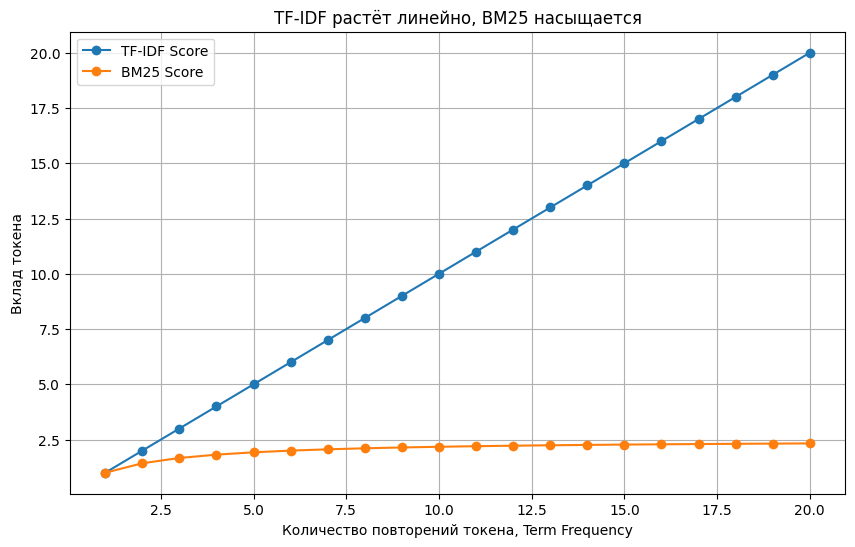

In [ ]:
import matplotlib.pyplot as plt

term_frequencies = list(range(1, 21))
tfidf_scores = [tf * 1.0 for tf in term_frequencies]

bm25_scores = [
    calculate_bm25_term_score(tf, 100, 100, 1.0)
    for tf in term_frequencies
]

plt.figure(figsize=(10, 6))
plt.plot(term_frequencies, tfidf_scores, marker='o', label='TF-IDF Score')
plt.plot(term_frequencies, bm25_scores, marker='o', label='BM25 Score')
plt.xlabel('Количество повторений токена, Term Frequency')
plt.ylabel('Вклад токена')
plt.title("TF-IDF растёт линейно, BM25 насыщается")
plt.grid(True)
plt.legend()
plt.show()

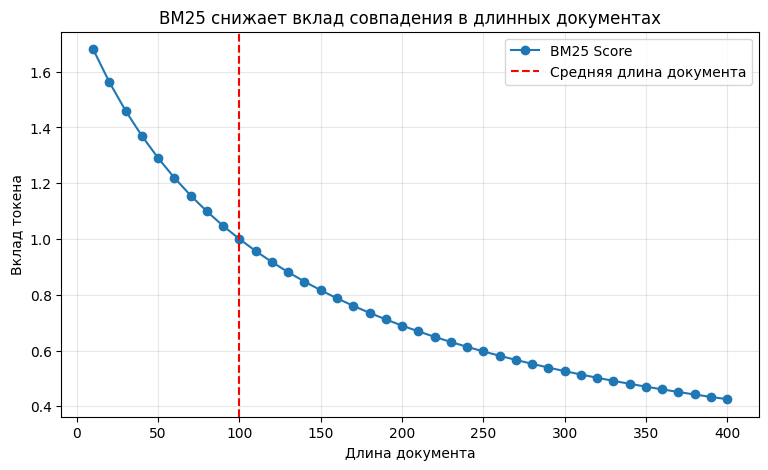

In [ ]:
document_lengths_for_plot = list(range(10, 401, 10))
average_length_for_plot = 100

length_scores = [
    calculate_bm25_term_score(1, dl, average_length_for_plot, 1.0, 1.5, 0.75)
    for dl in document_lengths_for_plot
]

plt.figure(figsize=(9, 5))
plt.plot(document_lengths_for_plot, length_scores, marker='o', label='BM25 Score')
plt.axvline(x=average_length_for_plot, color='r', linestyle='--', label='Средняя длина документа')
plt.xlabel('Длина документа')
plt.ylabel("Вклад токена")
plt.title("BM25 снижает вклад совпадения в длинных документах")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
raw_text = (
    "добрый день коллеги сегодня обсудим план релиза "
    "сначала метрики потом риски есть вопросы"
)

words = raw_text.split()

punctuation_after = {
    1: ",",
    2: "!",
    6: ":",
    8: ",",
    10: ".",
    12: "?"
}

capitalize_positions = {0, 3, 11}

def restore_from_labels(words: list[str], punctuation_after: dict[int, str], capitalize_positions: set[int]) -> str:
  restored_words = []
  for i, w in enumerate(words):
    if i in capitalize_positions:
      w = str(w[0]).upper() + w[1:]
    s = punctuation_after.get(i, '')
    w = w + s
    restored_words.append(w)
  return ' '.join(restored_words)

restore_from_labels(words, punctuation_after, capitalize_positions)


'Добрый день, коллеги! Сегодня обсудим план релиза: сначала метрики, потом риски. Есть вопросы?'

In [ ]:
def predict_capitalized_position(words: list[str], punctuation_after: dict[int, str]) -> set[int]:
  positions = set()
  if words:
    positions.add(0)
  for i, p in punctuation_after.items():
    if p in ['.', '!', '?'] and i < len(words)-1:
      positions.add(i + 1)
  return positions

cp = predict_capitalized_position(words, punctuation_after)
restore_from_labels(words, punctuation_after, cp)

0 добрый
1 день
2 коллеги
3 сегодня
4 обсудим
5 план
6 релиза
7 сначала
8 метрики
9 потом
10 риски
11 есть
12 вопросы


'Добрый день, коллеги! Сегодня обсудим план релиза: сначала метрики, потом риски. Есть вопросы?'

In [ ]:
def predict_punctuation(words: list[str]) -> dict[int, str]:
  punctuation_after = {}
  for i, w in enumerate(words):
    if i > 0 and words[i-1] == 'добрый' and w == 'день':
      punctuation_after[i] = ','
    if w == 'коллеги':
      punctuation_after[i] = '!'
    if w == 'релиза':
      punctuation_after[i] = ':'
    if w == 'метрики':
      punctuation_after[i] = ','
    if w == 'риски':
      punctuation_after[i] = '.'
    if w == 'вопросы':
      punctuation_after[i] = '?'
  return punctuation_after

print(predict_punctuation(words))

{1: ',', 2: '!', 6: ':', 8: ',', 10: '.', 12: '?'}


In [ ]:
def restore_punctuation(raw_text: str) -> str:
    # 1. Разбить текст на слова.
    words = raw_text.split()
    # 2. Предсказать пунктуацию.
    punctuation_after = predict_punctuation(words)
    # 3. Определить позиции заглавных букв.
    capitalize_positions = predict_capitalized_position(words, punctuation_after)
    # 4. Вызвать restore_from_labels().
    return restore_from_labels(words, punctuation_after, capitalize_positions)

restored_text = restore_punctuation(raw_text)
print(restored_text)

Добрый день, коллеги! Сегодня обсудим план релиза: сначала метрики, потом риски. Есть вопросы?


In [ ]:
PUNCTUATIONS = ["", ",", ".", "?"]

CASINGS = [
    "LOWER",       # слово
    "CAPITALIZE",  # Слово
    "UPPER"        # СЛОВО
]

In [ ]:
def encode_label(punctuation: str, casing: str) -> int:
    punctuation_id = PUNCTUATIONS.index(punctuation)
    casing_id = CASINGS.index(casing)
    class_id = punctuation_id * len(CASINGS) + casing_id

    return class_id

def decode_label(class_id: int) -> tuple[str, str]:
    punctuation_id = class_id // len(CASINGS)
    casing_id = class_id % len(CASINGS)

    return PUNCTUATIONS[punctuation_id], CASINGS[casing_id]

print(encode_label("", "LOWER"))          # 0
print(encode_label(",", "CAPITALIZE"))    # 4
print(encode_label("?", "UPPER"))         # 11

print(decode_label(0))   # ("", "LOWER")
print(decode_label(4))   # (",", "CAPITALIZE")
print(decode_label(11))  # ("?", "UPPER")

for class_id in range(12):
    punctuation, casing = decode_label(class_id)
    restored_text = encode_label(punctuation, casing)
    print(class_id, "->", punctuation, casing, "->", restored_text)

0
4
11
('', 'LOWER')
(',', 'CAPITALIZE')
('?', 'UPPER')
0 ->  LOWER -> 0
1 ->  CAPITALIZE -> 1
2 ->  UPPER -> 2
3 -> , LOWER -> 3
4 -> , CAPITALIZE -> 4
5 -> , UPPER -> 5
6 -> . LOWER -> 6
7 -> . CAPITALIZE -> 7
8 -> . UPPER -> 8
9 -> ? LOWER -> 9
10 -> ? CAPITALIZE -> 10
11 -> ? UPPER -> 11


In [ ]:
%pip install git+https://huggingface.co/kontur-ai/sbert_punc_case_ru

  Cloning https://huggingface.co/kontur-ai/sbert_punc_case_ru to /tmp/pip-req-build-12lanuix
  Running command git clone --filter=blob:none --quiet https://huggingface.co/kontur-ai/sbert_punc_case_ru /tmp/pip-req-build-12lanuix
  Resolved https://huggingface.co/kontur-ai/sbert_punc_case_ru to commit f778dc6c63bb0ec235a220488862509810e54583
  Preparing metadata (setup.py) ... done
  Created wheel for sbert_punc_case_ru: filename=sbert_punc_case_ru-0.2-py3-none-any.whl size=3535 sha256=ee33bde9f18be6114b5d5df2baaf5648e4e77ddf03a8ba60586a85d91ff1256f
  Stored in directory: /tmp/pip-ephem-wheel-cache-1f1qvgnm/wheels/3c/91/48/9e604ae8b595c65f22d4644895cb47795caf8cd6a81d80aaf0
Successfully built sbert_punc_case_ru


In [ ]:
from sbert_punc_case_ru import SbertPuncCase

model = SbertPuncCase()

rule_based_model = restore_punctuation(raw_text)
sbert_model = model.punctuate(raw_text)

print(raw_text)
print(rule_based_model)
print(sbert_model)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

добрый день коллеги сегодня обсудим план релиза сначала метрики потом риски есть вопросы
Добрый день, коллеги! Сегодня обсудим план релиза: сначала метрики, потом риски. Есть вопросы?
Добрый день, коллеги. Сегодня обсудим план релиза. сначала метрики, потом риски. Есть вопросы?


In [ ]:
def fix_sentence_capitalization(text: str) -> str:

    characters = list(text)
    should_capitalize = True

    for i, char in enumerate(characters):
        if should_capitalize and char.isalpha():
          char = char.upper()
          characters[i] = char
          should_capitalize = False
        if char in [".", "!", "?"]:
          should_capitalize = True

    return "".join(characters)

In [ ]:
model_result = (
    "Добрый день, коллеги. Сегодня обсудим план релиза. "
    "сначала метрики, потом риски. Есть вопросы?"
)

fixed_result = fix_sentence_capitalization(model_result)
print(fixed_result)

Добрый день, коллеги. Сегодня обсудим план релиза. Сначала метрики, потом риски. Есть вопросы?


In [ ]:
tests = [
    "привет. как дела?",
    "привет!   как дела?",
    "первая строка.\nвторая строка.",
    'он сказал: "привет". потом ушёл.'
]

for text in tests:
    print(repr(fix_sentence_capitalization(text)))

'Привет. Как дела?'
'Привет!   Как дела?'
'Первая строка.\nВторая строка.'
'Он сказал: "привет". Потом ушёл.'


In [ ]:
test_cases = {
    "ambiguity": "казнить нельзя помиловать",
    "names": "вчера анна встретила марину в тбилиси",
    "technical_terms": "мы используем openai api и pytorch",
    "asr_errors": "завтра мы абсудим результаты эксперемента",
    "dialogue": "ты придешь сегодня да конечно после шести"
}

for case_name, text in test_cases.items():

    model_result = model.punctuate(text)
    fixed_result = fix_sentence_capitalization(model_result)

    print(case_name)
    print("RAW:  ", text)
    print("MODEL:", model_result)
    print("FIXED:", fixed_result)
    print()

ambiguity
RAW:   казнить нельзя помиловать
MODEL: Казнить нельзя помиловать.
FIXED: Казнить нельзя помиловать.

names
RAW:   вчера анна встретила марину в тбилиси
MODEL: Вчера Анна встретила Марину в Тбилиси.
FIXED: Вчера Анна встретила Марину в Тбилиси.

technical_terms
RAW:   мы используем openai api и pytorch
MODEL: Мы используем Openai API и PYTORCH.
FIXED: Мы используем Openai API и PYTORCH.

asr_errors
RAW:   завтра мы абсудим результаты эксперемента
MODEL: Завтра мы абсудим результаты эксперемента.
FIXED: Завтра мы абсудим результаты эксперемента.

dialogue
RAW:   ты придешь сегодня да конечно после шести
MODEL: Ты придешь сегодня, да, конечно, после шести.
FIXED: Ты придешь сегодня, да, конечно, после шести.



In [36]:
import random
from collections import Counter
from collections.abc import Iterable, Mapping, Sequence
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset

SEED = 42
DATA_DIR = Path('/content')

random.seed(SEED)
torch.manual_seed(SEED)
ID_TO_LANGUAGE = {0: 'ru', 1: 'en', 2: 'es'}
UNKNOWN_TOKEN = '<UNK>'
BATCH_SIZE = 128
HIDDEN_SIZE = 64
NUM_CLASSES = len(ID_TO_LANGUAGE)
EPOCHS = 10
LEARNING_RATE = 1e-2
ARTIFACT_PATH = Path('/content/language_classifier.pt')

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')


def load_csv(path: str | Path) -> tuple[list[str], list[int]]:
    dataframe = pd.read_csv(path)
    texts = dataframe['text'].astype(str).tolist()
    labels = dataframe['label'].astype(int).tolist()
    return texts, labels

train_texts, train_labels = load_csv(DATA_DIR/'train.csv')
val_texts, val_labels = load_csv(DATA_DIR/'validation.csv')
test_texts, test_labels = load_csv(DATA_DIR/'test.csv')
print('Train:', len(train_texts))
print('Val:', len(val_texts))
print('Test:', len(test_texts))

'''
for names, labels in {
    'Train': train_labels,
    'Val': val_labels,
    'Test': test_labels
    }.items():
    readable_counts = {
        ID_TO_LANGUAGE[label]: count
        for label, count in sorted(Counter(labels).items())
    }
    plt.figure(figsize=(10, 5))
    plt.bar(readable_counts.keys(), readable_counts.values())
    plt.title(names)
    print(names, readable_counts)
plt.show()
'''

indices = random.sample(range(len(train_texts)), k=3)
for i in indices:
    print(train_texts[i], ID_TO_LANGUAGE[train_labels[i]])

def build_vocabulary(texts: Iterable[str]) -> list[str]:
    characters = {
        c
        for t in texts
        for c in t.lower()
    }
    return [UNKNOWN_TOKEN, *sorted(characters)]

vocabulary = build_vocabulary(train_texts)
character_to_id = {
    c: i for i, c in enumerate(vocabulary)
}

print("Размер словаря:", len(vocabulary))
print("Первые 20 символов словаря:", vocabulary[:20])

def text_to_bag_of_characters(
        text: str,
        character_to_id: Mapping[str, int]
) -> torch.Tensor:
    features = torch.zeros(len(character_to_id), dtype=torch.float32)
    normalized_text = text.lower()

    for c in normalized_text:
        c_id = character_to_id.get(c, 0)
        features[c_id] += 1

    if normalized_text:
        features /= len(normalized_text)
    return features

example_features = text_to_bag_of_characters('Hello!', character_to_id=character_to_id)
print(example_features.shape)
print(example_features)
print(example_features.sum().item())
print(torch.count_nonzero(example_features).item())

class LanguageDataset(Dataset):
    def __init__(self,
            texts: Sequence[str],
            labels: Sequence[int],
            vocabulary: Sequence[str] | None = None,
            ) -> None:
        self.texts = texts
        self.labels = labels
        self.vocabulary = (
            build_vocabulary(self.texts)
            if vocabulary is None
            else list(vocabulary)
        )
        self.character_to_id = {
            c: i for i, c in enumerate(self.vocabulary)
        }
    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index) -> tuple[torch.Tensor, str, torch.Tensor]:
        text = self.texts[index]
        features = text_to_bag_of_characters(
            self.texts[index],
            self.character_to_id
        )
        label = self.labels[index]
        return features, text, label


print(len(train_texts), len(train_labels))
train_dataset = LanguageDataset(train_texts, train_labels)
val_dataset = LanguageDataset(val_texts, val_labels, train_dataset.vocabulary)
test_dataset = LanguageDataset(test_texts, test_labels, train_dataset.vocabulary)

print(len(train_dataset))
features, text, label = train_dataset[0]
print(features.shape, text, label)

loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=loader_generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

batch_features, batch_text, batch_labels = next(iter(train_loader))
print(batch_features.shape, batch_features.dtype)
print(batch_labels.shape, batch_labels.dtype)
print(len(train_loader))

class Classifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int) -> None:
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
        )
    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.network(features)

class LayerNormSwishClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int) -> None:
        super().__init__()
        wide_size = hidden_size * 2
        self.network = nn.Sequential(
            nn.Linear(input_size, wide_size),
            nn.LayerNorm(wide_size),
            nn.SiLU(),
            nn.Linear(wide_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, output_size),
        )
    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.network(features)

class SwiGLU(nn.Module):
    def __init__(self, input_size: int, output_size: int) -> None:
        super().__init__()
        self.projection = nn.Linear(input_size, output_size * 2)
    def forward(self, features: torch.Tensor) -> torch.Tensor:
        value, gate = self.projection(features).chunk(2, dim=-1)
        return value * nn.functional.silu(gate)

class SwiGLUClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int) -> None:
        super().__init__()
        self.network = nn.Sequential(
            nn.LayerNorm(input_size),
            SwiGLU(input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            SwiGLU(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, output_size),
        )
    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.network(features)

def count_trainable_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_classes = {
    'ReLU baseline': Classifier,
    'LayerNorm + Swish': LayerNormSwishClassifier,
    'LayerNorm + SwiGLU': SwiGLUClassifier
}

for n, m in model_classes.items():
    candidate = m(
        input_size=len(train_dataset.vocabulary),
        hidden_size=64,
        output_size=len(ID_TO_LANGUAGE)
    )
    candidate_logits = candidate(batch_features)
    print(f'{n:>20}: parameters={count_trainable_parameters(candidate):>6},')
    print(f'output={tuple(candidate_logits.shape)}')


MODEL_CLASS = SwiGLUClassifier

model = MODEL_CLASS(
    input_size=len(train_dataset.vocabulary),
    hidden_size=HIDDEN_SIZE,
    output_size=NUM_CLASSES,
).to(device)

with torch.no_grad():
    example_logits = model(batch_features.to(device))
print(model)
print('Input:', batch_features.shape)
print('Output:', example_logits.shape)

def run_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    optimizer: torch.optim.Optimizer | None = None
) -> tuple[float, float]:
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_correct = 0.0
    total_examples = 0

    with torch.set_grad_enabled(is_training):
        for f, _, l in data_loader:
            f = f.to(device)
            l = l.to(device)

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(f)
            loss = loss_function(logits, l)

            if is_training:
                loss.backward()
                optimizer.step()

            batch_size = l.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == l).sum().item()
            total_examples += batch_size

    if total_examples == 0:
        raise ValueError("DataLoader must contain at least one example")
    return total_loss / total_examples, total_correct / total_examples

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
}

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = run_epoch(
        model,
        train_loader,
        loss_function,
        optimizer
    )
    val_loss, val_acc = run_epoch(
        model,
        val_loader,
        loss_function
    )

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:02d} / {EPOCHS}: ')
    print(f'{train_loss=:.4f}, {train_acc=:.4f}')
    print(f'{val_loss=:.4f}, {val_acc=:.4f}')

print('Loss by epoch')
print('epoch    train   validation')
for epoch, (train_loss, val_loss) in enumerate(
    zip(history['train_loss'], history['val_loss']),
    start=1
):
    print(f'{epoch:>5}  | {train_loss:.4f}  | {val_loss:.4f}')

test_loss, test_acc = run_epoch(
    model,
    test_loader,
    loss_function
)
print(f'{test_loss=:.4f}, {test_acc=:.4f}')

def confusion_matrix(
        model: nn.Module,
        data_loader: DataLoader,
        number_of_classes: int
) -> torch.Tensor:
    matrix = torch.zeros((number_of_classes, number_of_classes), dtype=torch.int64)
    model.eval()
    with torch.no_grad():
        for f, _, l in data_loader:
            pred = model(f.to(device)).argmax(dim=1).to(device)
            for t, p in zip(l, pred):
                matrix[t, p] += 1
    return matrix

matrix = confusion_matrix(model, test_loader, NUM_CLASSES)
language_names = [ID_TO_LANGUAGE[i] for i in range(NUM_CLASSES)]
print("     " + " ".join(f"{name:>6}" for name in language_names))
for l, r in zip(language_names, matrix):
    print(f"{l:>3}: " + " ".join(f"{v.item():>6}" for v in r))

model.eval()
errors = []
with torch.no_grad():
    for ftrs, txts, lbls in test_loader:
        logits = model(ftrs.to(device))
        probs = logits.softmax(dim=1).to(device)
        preds = logits.argmax(dim=1)

        for t, tl, pl, p in zip(
            txts, lbls, preds, probs
        ):
            if pl != tl:
                errors.append({
                    'text': t,
                    'labels': ID_TO_LANGUAGE[tl.item()],
                    'predicted': ID_TO_LANGUAGE[pl.item()],
                    'confidence': p[pl].item()
                })
for e in errors:
    print(f'Текст: {e['text']}, '
          f'Истинный класс: {e['labels']}, '
          f'Предсказанный класс: {e['predicted']}, '
          f'Уверенность: {e['confidence']}')

'''
ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        'model_state_dict': model.state_dict(),
        'model_class': model.__class__.__name__,
        'vocabulary': train_dataset.vocabulary,
        'hidden_size': HIDDEN_SIZE,
        'id_to_language': ID_TO_LANGUAGE
    }, ARTIFACT_PATH,
)
print(f"Saved to {ARTIFACT_PATH}")
'''


Train: 10500
Val: 1500
Test: 1500
Para tija Aero d lujo. Poca autonomía en según q modo creo es
Lo compré para sustituir un encendedor en Renault Megane II pero resulta que no es compatible. Por importe reducido, no lo he devuelto - pero convendría indicar una lista de modelos (al menos, los más corrientes) de coches donde es compatible. es
Ну , я думаю , хотя мне хорошо , что ты сказал , что как можно определить , что такое вторжение в частную жизнь , потому что если это случай , когда дерево падает в лес , и я не чувствую себя вторглись тогда , возможно , моя конфиденциальность не имеет . Потому что у меня нет чувства , что мое состояние частной жизни было вторглись . ru
Размер словаря: 152
Первые 20 символов словаря: ['<UNK>', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2']
torch.Size([152])
tensor([0.0000, 0.0000, 0.1667, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0

'\nARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)\n\ntorch.save(\n    {\n        \'model_state_dict\': model.state_dict(),\n        \'model_class\': model.__class__.__name__,\n        \'vocabulary\': train_dataset.vocabulary,\n        \'hidden_size\': HIDDEN_SIZE,\n        \'id_to_language\': ID_TO_LANGUAGE\n    }, ARTIFACT_PATH,\n)\nprint(f"Saved to {ARTIFACT_PATH}")\n'

In [37]:
def predict_language(
    text: str,
    model: nn.Module,
    vocabulary: Sequence[str],
    id_to_language: Mapping[int, str],
    device: torch.device,
) -> tuple[str, list[float]]:
    '''Predict a language and return probabilities for one non-empty text.'''
    if not text.strip():
        raise ValueError("Text must not be empty")

    character_to_id = {
        character: index
        for index, character in enumerate(vocabulary)
    }
    features = text_to_bag_of_characters(text, character_to_id)

    model.eval()
    with torch.no_grad():
        logits = model(features.unsqueeze(0).to(device))
        probabilities = logits.softmax(dim=1).squeeze(0).cpu()

    predicted_id = probabilities.argmax().item()
    return id_to_language[predicted_id], probabilities.tolist()

In [38]:
examples = [
    "Где находится мой заказ?",
    "Where is my order?",
    "¿Dónde está mi pedido?",
    'Как ты однажды мне сказал, the fastest bird has all of bugs',
    'Привет'
]

for text in examples:
    language, probabilities = predict_language(
        text,
        model,
        train_dataset.vocabulary,
        ID_TO_LANGUAGE,
        device,
    )
    readable_probabilities = {
        ID_TO_LANGUAGE[index]: round(probability, 3)
        for index, probability in enumerate(probabilities)
    }
    print(repr(text), "->", language, readable_probabilities)

'Где находится мой заказ?' -> ru {'ru': 1.0, 'en': 0.0, 'es': 0.0}
'Where is my order?' -> en {'ru': 0.0, 'en': 1.0, 'es': 0.0}
'¿Dónde está mi pedido?' -> es {'ru': 0.0, 'en': 0.0, 'es': 1.0}
'Как ты однажды мне сказал, the fastest bird has all of bugs' -> en {'ru': 0.271, 'en': 0.726, 'es': 0.002}
'Привет' -> ru {'ru': 1.0, 'en': 0.0, 'es': 0.0}


In [6]:
def get_character_ngrams(text: str, n: int) -> list[str]:
    text = text.lower()
    ngrams = []
    for i in range(len(text) - n + 1):
      ngrams.append(text[i:i + n])
    return ngrams

def build_ngram_vocabulary(
    texts: Iterable[str],
    n: int,
) -> list[str]:
    ngram_vocab = set()
    for text in texts:
      ngrams = get_character_ngrams(text, n)
      ngram_vocab.update(ngrams)
    return [UNKNOWN_TOKEN, *sorted(ngram_vocab)]

get_character_ngrams("Mama", n=2)
texts = ["Mama", "Am"]

build_ngram_vocabulary(texts, n=2)

['<UNK>', 'am', 'ma']

In [7]:
ngram_vocabulary = build_ngram_vocabulary(train_texts, n=2)

ngram_to_id = {
    ngram: index
    for index, ngram in enumerate(ngram_vocabulary)
}

unknown_id = ngram_to_id[UNKNOWN_TOKEN]

In [8]:
len(ngram_vocabulary)

2746

In [9]:
def text_to_ngram_bag(
    text: str,
    n: int,
    ngram_to_id: dict[str, int],
) -> torch.Tensor:
    vec = torch.zeros(len(ngram_to_id), dtype=torch.float32)
    ngrams = get_character_ngrams(text, n)
    for ngram in ngrams:
        ngram_id = ngram_to_id.get(ngram, unknown_id)
        vec[ngram_id] += 1
    if ngrams:
        vec /= len(ngrams)
    return vec

In [10]:
class LanguageDataset(Dataset):
    def __init__(self,
        texts: Sequence[str],
        labels: Sequence[int],
        n: int = 2,
        ngram_vocabulary: Sequence[str] | None = None) -> None:
        self.texts = texts
        self.labels = labels
        self.n = n
        self.ngram_vocabulary = (
            build_ngram_vocabulary(self.texts, self.n)
            if ngram_vocabulary is None
            else list(ngram_vocabulary)
        )
        self.ngram_to_id = {
            ng: i for i, ng in enumerate(self.ngram_vocabulary)
        }
    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index) -> tuple[torch.Tensor, str, torch.Tensor]:
        text = self.texts[index]
        features = text_to_ngram_bag(
            text,
            self.n,
            self.ngram_to_id
        )
        label = torch.tensor(self.labels[index], dtype=torch.long)
        return features, text, label

In [11]:
print(len(train_texts), len(train_labels))
train_dataset = LanguageDataset(train_texts, train_labels, n = 2)
val_dataset = LanguageDataset(val_texts, val_labels, n = 2, ngram_vocabulary = train_dataset.ngram_vocabulary)
test_dataset = LanguageDataset(test_texts, test_labels, ngram_vocabulary = train_dataset.ngram_vocabulary)

print(len(train_dataset.ngram_vocabulary))

print(
    train_dataset.ngram_vocabulary
    == val_dataset.ngram_vocabulary
)

print(
    train_dataset.ngram_vocabulary
    == test_dataset.ngram_vocabulary
)

features, text, label = train_dataset[0]

print(features.shape)
print(features.sum())
print(text)
print(label, label.dtype)

10500 10500
2746
True
True
torch.Size([2746])
tensor(1.)
Он увеличил давление .
tensor(0) torch.int64


In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=loader_generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

batch_features, batch_texts, batch_labels = next(iter(train_loader))

print("features:", batch_features.shape)
print("texts:", len(batch_texts))
print("labels:", batch_labels.shape)
print("dtype:", batch_features.dtype, batch_labels.dtype)
print("Первая сумма:", batch_features[0].sum())

features: torch.Size([128, 2746])
texts: 128
labels: torch.Size([128])
dtype: torch.float32 torch.int64
Первая сумма: tensor(1.)


In [13]:
print(train_loader.dataset is train_dataset)
print(hasattr(train_loader.dataset, "ngram_vocabulary"))
print(len(train_dataset.ngram_vocabulary))
print(train_dataset.ngram_vocabulary[:20])

True
True
2746
['<UNK>', ' !', ' "', ' #', ' $', ' %', ' &', " '", ' (', ' )', ' *', ' +', ' ,', ' -', ' .', ' /', ' 0', ' 1', ' 2', ' 3']


In [14]:
MODEL_CLASS = SwiGLUClassifier

bigram_model = MODEL_CLASS(
    input_size=len(train_dataset.ngram_vocabulary),
    hidden_size=HIDDEN_SIZE,
    output_size=NUM_CLASSES,
).to(device)

with torch.no_grad():
    example_logits = bigram_model(batch_features.to(device))
print(bigram_model)
print('Input:', batch_features.shape)
print('Output:', example_logits.shape)

print(
    "Параметры:",
    sum(parameter.numel() for parameter in bigram_model.parameters()),
)

SwiGLUClassifier(
  (network): Sequential(
    (0): LayerNorm((2746,), eps=1e-05, elementwise_affine=True)
    (1): SwiGLU(
      (projection): Linear(in_features=2746, out_features=128, bias=True)
    )
    (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (3): SwiGLU(
      (projection): Linear(in_features=64, out_features=128, bias=True)
    )
    (4): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (5): Linear(in_features=64, out_features=3, bias=True)
  )
)
Input: torch.Size([128, 2746])
Output: torch.Size([128, 3])
Параметры: 365879


In [15]:
random.seed(SEED)
torch.manual_seed(SEED)

bigram_model = MODEL_CLASS(
    input_size=len(train_dataset.ngram_vocabulary),
    hidden_size=HIDDEN_SIZE,
    output_size=NUM_CLASSES,
).to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(bigram_model.parameters(), lr=LEARNING_RATE)

history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
}

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = run_epoch(
        bigram_model,
        train_loader,
        loss_function,
        optimizer
    )
    val_loss, val_acc = run_epoch(
        bigram_model,
        val_loader,
        loss_function
    )

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:02d} / {EPOCHS}: ')
    print(f'{train_loss=:.4f}, {train_acc=:.4f}')
    print(f'{val_loss=:.4f}, {val_acc=:.4f}')

print('Loss by epoch')
print('epoch    train   validation')
for epoch, (train_loss, val_loss) in enumerate(
    zip(history['train_loss'], history['val_loss']),
    start=1
):
    print(f'{epoch:>5}  | {train_loss:.4f}  | {val_loss:.4f}')

test_loss, test_acc = run_epoch(
    bigram_model,
    test_loader,
    loss_function
)
print(f'{test_loss=:.4f}, {test_acc=:.4f}')

Epoch 01 / 10: 
train_loss=0.0367, train_acc=0.9865
val_loss=0.0020, val_acc=0.9993
Epoch 02 / 10: 
train_loss=0.0010, train_acc=0.9998
val_loss=0.0056, val_acc=0.9987
Epoch 03 / 10: 
train_loss=0.0025, train_acc=0.9995
val_loss=0.0019, val_acc=0.9993
Epoch 04 / 10: 
train_loss=0.0001, train_acc=1.0000
val_loss=0.0012, val_acc=0.9993
Epoch 05 / 10: 
train_loss=0.0000, train_acc=1.0000
val_loss=0.0006, val_acc=0.9993
Epoch 06 / 10: 
train_loss=0.0000, train_acc=1.0000
val_loss=0.0006, val_acc=0.9993
Epoch 07 / 10: 
train_loss=0.0000, train_acc=1.0000
val_loss=0.0006, val_acc=0.9993
Epoch 08 / 10: 
train_loss=0.0000, train_acc=1.0000
val_loss=0.0006, val_acc=0.9993
Epoch 09 / 10: 
train_loss=0.0000, train_acc=1.0000
val_loss=0.0007, val_acc=0.9993
Epoch 10 / 10: 
train_loss=0.0000, train_acc=1.0000
val_loss=0.0007, val_acc=0.9993
Loss by epoch
epoch    train   validation
    1  | 0.0367  | 0.0020
    2  | 0.0010  | 0.0056
    3  | 0.0025  | 0.0019
    4  | 0.0001  | 0.0012
    5  | 0.000

In [21]:
matrix = confusion_matrix(bigram_model, test_loader, NUM_CLASSES)
language_names = [ID_TO_LANGUAGE[i] for i in range(NUM_CLASSES)]
print("     " + " ".join(f"{name:>6}" for name in language_names))
for l, r in zip(language_names, matrix):
    print(f"{l:>3}: " + " ".join(f"{v.item():>6}" for v in r))

bigram_model.eval()
errors = []
with torch.no_grad():
    for ftrs, txts, lbls in test_loader:
        logits = bigram_model(ftrs.to(device))
        probs = logits.softmax(dim=1).to(device)
        preds = logits.argmax(dim=1)

        for t, tl, pl, p in zip(
            txts, lbls, preds, probs
        ):
            if pl != tl:
                errors.append({
                    'text': t,
                    'labels': ID_TO_LANGUAGE[tl.item()],
                    'predicted': ID_TO_LANGUAGE[pl.item()],
                    'confidence': p[pl].item()
                })
for e in errors:
    print(f'Текст: {e['text']}, '
          f'Истинный класс: {e['labels']}, '
          f'Предсказанный класс: {e['predicted']}, '
          f'Уверенность: {e['confidence']}')




         ru     en     es
 ru:    500      0      0
 en:      0    499      1
 es:      0      0    500
Текст: It loses data and files become corrupt on a regular basis. Piece of junk., Истинный класс: en, Предсказанный класс: es, Уверенность: 0.6224014163017273


In [32]:
def predict_language(
    text: str,
    model: nn.Module,
    vocabulary: Sequence[str],
    id_to_language: Mapping[int, str],
    device: torch.device,
) -> tuple[str, list[float]]:
    '''Predict a language and return probabilities for one non-empty text.'''
    if not text.strip():
        raise ValueError("Text must not be empty")

    ngram_to_id = {
            ng: i for i, ng in enumerate(vocabulary)
        }
    features = text_to_ngram_bag(text, n=2, ngram_to_id=ngram_to_id)

    model.eval()
    with torch.no_grad():
        logits = model(features.unsqueeze(0).to(device))
        probabilities = logits.softmax(dim=1).squeeze(0).cpu()

    predicted_id = probabilities.argmax().item()
    return id_to_language[predicted_id], probabilities.tolist()

In [33]:
examples = [
    "Где находится мой заказ?",
    "Where is my order?",
    "¿Dónde está mi pedido?",
    'Как ты однажды мне сказал, the fastest bird has all of bugs',
    'Привет'
]

for text in examples:
    language, probabilities = predict_language(
        text,
        bigram_model,
        train_dataset.ngram_vocabulary,
        ID_TO_LANGUAGE,
        device,
    )
    readable_probabilities = {
        ID_TO_LANGUAGE[index]: round(probability, 3)
        for index, probability in enumerate(probabilities)
    }
    print(repr(text), "->", language, readable_probabilities)

'Где находится мой заказ?' -> ru {'ru': 1.0, 'en': 0.0, 'es': 0.0}
'Where is my order?' -> en {'ru': 0.0, 'en': 1.0, 'es': 0.0}
'¿Dónde está mi pedido?' -> es {'ru': 0.0, 'en': 0.0, 'es': 1.0}
'Как ты однажды мне сказал, the fastest bird has all of bugs' -> en {'ru': 0.325, 'en': 0.675, 'es': 0.0}
'Привет' -> ru {'ru': 1.0, 'en': 0.0, 'es': 0.0}


In [39]:
texts = [
    "Hello world!",
    "Привет, мир!",
    "¡Hola, mundo!",
]

In [42]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "FacebookAI/xlm-roberta-base"
)

encoded = tokenizer(
    texts,
    padding=True,
    return_tensors="pt",
)
print(encoded)
print(encoded.keys())

print(encoded["input_ids"])
print(encoded["input_ids"].shape)

print(encoded["attention_mask"])
print(encoded["attention_mask"].shape)


{'input_ids': tensor([[     0,  35378,   8999,     38,      2,      1,      1,      1],
        [     0,   1813,  18454,      4,  11373,     38,      2,      1],
        [     0,  14701, 113251,     11,      4,   3307,     38,      2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]])}
KeysView({'input_ids': tensor([[     0,  35378,   8999,     38,      2,      1,      1,      1],
        [     0,   1813,  18454,      4,  11373,     38,      2,      1],
        [     0,  14701, 113251,     11,      4,   3307,     38,      2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]])})
tensor([[     0,  35378,   8999,     38,      2,      1,      1,      1],
        [     0,   1813,  18454,      4,  11373,     38,      2,      1],
        [     0,  14701, 113251,     11,      4,   3307,     38,      2]])
torch.Size([3, 8])
tensor([[1, 1, 1, 1, 1, 0, 0